# Buying a dollar for ninety cents — does the closed-end fund discount pay you to wait? 🏷️
### When a fund costs less than the stuff it owns, is that free money — or a trap?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Pays_you_to_wait%3F: Confirmed](https://img.shields.io/badge/Pays_you_to_wait%3F-Confirmed-8b949e?style=flat-square)

Here's a genuine market oddity. A **closed-end fund (CEF)** owns a pile of stocks, but trades on the exchange at whatever price buyers and sellers agree on — which is often **less** than the value of what it holds. Buy it and, on paper, you own a dollar of assets for ninety cents. The folklore (and a real strand of finance research) says: buy the **deepest discounts** and wait — the gap closes, and you pocket the difference.

Does it actually work? On our data, **surprisingly, yes** — the widest-discount funds do out-earn the narrowest, market-neutral, and it isn't a fluke of how we measured it. But the payment is **small, fades after 2010, and needs trades you mostly can't make**. This notebook tells that story in plain English.

> 📓 **Plain-language layer.** Want the _t_-stats, the block bootstrap and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** A fund's true daily **NAV** (the value of its holdings) isn't free on yfinance. So we **build a transparent proxy**: we line each fund up against a published benchmark for what it owns (an S&P-500 fund vs SPY, a utilities fund vs XLU) and call it 'cheap' when its price lags that benchmark. We say **proxy** throughout. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from closed_end_fund_discount import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    REAL = data.load_real()
    MP = st.monthly_panels(REAL["disc"], REAL["px"])
    LS = st.long_short_returns(MP["disc"], MP["fret"])
    LO = st.long_only_excess(MP["disc"], MP["fret"])
else:
    REAL = MP = LS = LO = None
print("real CEF cache present:", HAVE_REAL,
      "| usable CEFs:", (0 if REAL is None else REAL["disc"].shape[1]),
      "| months:", (0 if LS is None else len(LS.dropna())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1995-01-03', 'end': '2026-06-18', 'days': 7918, 'years': 31.5, 'n_cef': 18, 'months': 377, 'ls': (0.55, 6.6, 56, 3.72, 0.002, 0.66), 'lo': (0.253, 3.03, 55, 2.89, 0.012, 0.52), 'gross_ann': 6.6, 'net_ann': 1.8, 'breakeven_bps': 27.5, 'placebo': (0.55, 0.006, 0.126, 0.0), 'beta': -0.003, 'alpha_mo': 0.553, 'robust': [(0.25, 9.74, 4.34, 0.001, 0.77), (0.3333333333333333, 6.6, 3.72, 0.002, 0.66), (0.4, 6.1, 3.91, 0.001, 0.7)], 'sub': [('1995-2010', 10.64, 3.41, 0.86), ('2011-2026', 2.57, 1.56, 0.39)], 'syn': [(0.0, -0.34, -0.19, 0.846, -0.03), (0.3, 107.07, 48.57, 0.0, 8.87)]}


real CEF cache present: True | usable CEFs: 18 | months: 377


## The answer first

| Question | Answer |
|---|---|
| Do deep-discount funds really out-earn the rest? | **Yes — by about 6.6% a year**, buying the widest discounts and shorting the narrowest. That clears the bar for a *real* effect. |
| Is it just the market in disguise? | **No.** The bet is market-neutral (it barely moves with the S&P) — and if we **scramble** which fund is 'cheap', the edge vanishes. The discount ranking is doing real work. |
| So it's free money? | **Not so fast.** After trading costs it drops to **~1.8%/yr**, the short side needs **hard-to-borrow** tiny funds, and the effect has **faded since 2010**. |
| Bottom line? | **Real, but barely bankable.** A true pattern you can *see* clearly and *bank* only weakly — the gap between 'statistically real' and 'tradable.' |

> The discount really does pay you to wait. It just doesn't pay you *much*, *reliably*, or *at scale*.

## 1 · The claim

> *"A closed-end fund has a fixed number of shares, so its price floats free of the value of what it owns. When that price sinks well **below** NAV — a deep discount — you're buying assets at a markdown. The discount mean-reverts back toward NAV, so the widest discounts pay you to wait."*

Unlike an ordinary mutual fund or ETF (which you can create/redeem at NAV), a CEF's share count is locked, so supply and demand for the *shares* — not the *holdings* — set the price. Discounts of 10–20% are common and persistent. The pitch is intuitive: pay less than the holdings are worth, wait for the gap to close, win twice. We'll rebuild the discount and put that pitch under a microscope.

## 2 · So what?

If a *cheap* fund reliably out-earns an *expensive* one, that's a clean, near-market-neutral edge — you're not betting on the market going up, just on cheap closing the gap to dear. That would be valuable and a little embarrassing for efficient markets (why does the discount persist at all?). But two catches lurk. (1) A high *average* return means nothing if it's **costs and shorting** that eat it — the short leg here is small, illiquid funds that are **hard to borrow**. (2) A real edge can **decay** once everyone knows it. So the question isn't just 'does cheap beat dear?' but 'does it beat dear by **enough**, **net**, **still**?'

## 3 · How would we even know?

We rebuild the discount on a **transparent proxy**. For each of **18** long-listed equity CEFs we pick a benchmark for what it owns, and call the fund 'cheap' when its price lags that benchmark (and 'dear' when it leads). Then, every month:

1. **Rank the funds** from cheapest (widest discount) to dearest.
2. **Buy the cheap third, sell the dear third**, hold one month, repeat — entering the month *after* we see the discount (no peeking).
3. **Stress the luck.** Compare the spread to zero with a _t_-test and a bootstrap, and — the key honesty check — **scramble** which fund is labelled cheap and confirm the edge disappears. Over **32 years** that's **377** monthly bets.

## 4 · The teardown — let's actually look

**First, here's a discount.** One fund's proxy discount over time — diving cheap, drifting back. That wandering, mean-reverting gap is the whole game.

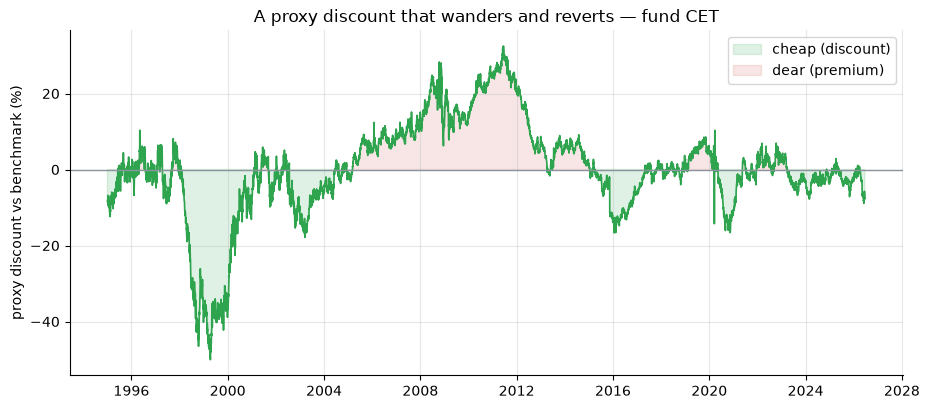

CET: proxy discount swings from -50% to +33% around its own mean


In [2]:
if HAVE_REAL:
    d = REAL['disc']
    name = d.notna().sum().sort_values().index[-1]   # a long-history fund
    s = d[name].dropna()*100
    fig, ax = plt.subplots(figsize=(9.4, 4.2))
    ax.plot(s.index, s.values, c=GREEN, lw=1.2)
    ax.axhline(0, c=GREY, lw=1)
    ax.fill_between(s.index, s.values, 0, where=s.values<0, color=GREEN, alpha=.15, label='cheap (discount)')
    ax.fill_between(s.index, s.values, 0, where=s.values>0, color=RED, alpha=.12, label='dear (premium)')
    ax.set_title(f'A proxy discount that wanders and reverts — fund {name}')
    ax.set_ylabel('proxy discount vs benchmark (%)'); ax.legend()
    plt.tight_layout(); plt.show()
    print(f'{name}: proxy discount swings from {s.min():.0f}% to {s.max():+.0f}% around its own mean')
else:
    print('no cache — see docs/results.md for the frozen headline numbers')

See how it dips deep and crawls back? *That* reversion is what 'buy the discount' is betting on. Now: does buying the cheap funds and shorting the dear ones actually pay?

**Cheap minus dear — does it grow?** Below, $1 compounded into the monthly wide-minus-narrow discount spread (market-neutral), next to a flat line for reference.

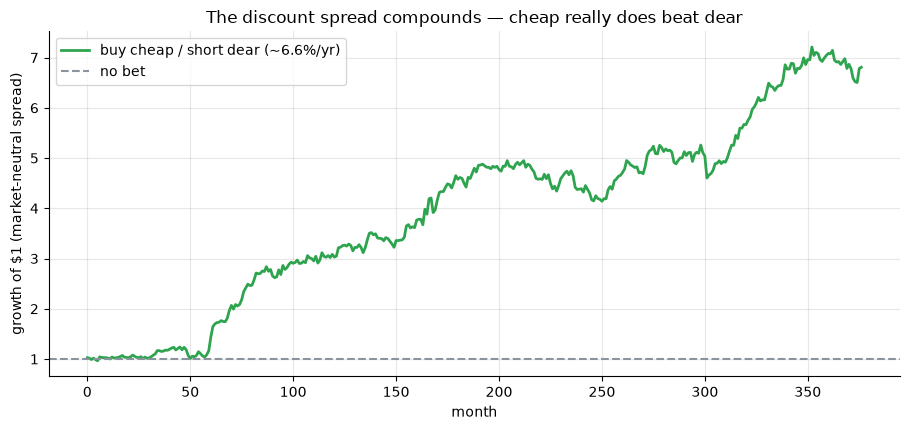

377 monthly bets, win-rate 56%, grows to 6.8x gross


In [3]:
if HAVE_REAL:
    ls = LS.dropna()
    curve = (1+ls).cumprod()
    ann = R['ls'][1]
else:
    rng = np.random.default_rng(367)
    ls = pd.Series(rng.normal(R['ls'][0]/100, 0.0287, R['months']))
    curve = (1+ls).cumprod(); ann = R['ls'][1]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(range(len(curve)), curve.values, c=GREEN, lw=2, label=f'buy cheap / short dear (~{ann:.1f}%/yr)')
ax.axhline(1.0, c=GREY, ls='--', label='no bet')
ax.set_xlabel('month'); ax.set_ylabel('growth of $1 (market-neutral spread)')
ax.set_title('The discount spread compounds — cheap really does beat dear')
ax.legend(); plt.tight_layout(); plt.show()
print(f'{len(ls)} monthly bets, win-rate {(ls>0).mean()*100:.0f}%, grows to {curve.iloc[-1]:.1f}x gross')

It climbs. The cheap-minus-dear spread earns about **6.6%/yr** and wins **56%** of months — and it barely budges with the stock market (β ≈ -0.00). So far the folklore looks *right*. But could this be an accident of how we ranked the funds? Time for the honesty check.

**The scramble test.** If we randomly **shuffle** which fund is labelled 'cheap' each month — destroying the real ranking — a genuine signal should die. Here's the spread before and after scrambling.

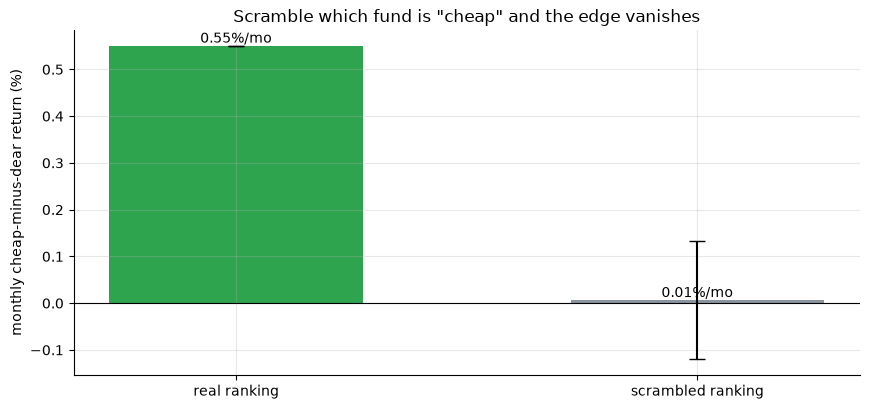

real ranking 0.55%/mo  ->  scrambled 0.01% +/- 0.13%  (p=0.000)


In [4]:
obs = R['placebo'][0]; shuf = R['placebo'][1]; shuf_sd = R['placebo'][2]
fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.bar(['real ranking','scrambled ranking'], [obs, shuf], yerr=[0, shuf_sd],
       color=[GREEN, GREY], capsize=6, width=.55)
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate([obs, shuf]): ax.annotate(f'{v:.2f}%/mo',(i,v),ha='center',va='bottom')
ax.set_ylabel('monthly cheap-minus-dear return (%)')
ax.set_title('Scramble which fund is "cheap" and the edge vanishes')
plt.tight_layout(); plt.show()
print(f'real ranking {obs:.2f}%/mo  ->  scrambled {shuf:.2f}% +/- {shuf_sd:.2f}%  (p={R["placebo"][3]:.3f})')

There's the proof it's not an artefact: scramble the discounts and the spread collapses to **zero**. The *ranking* — buying the genuinely cheap funds — is what carries the return. This is a **real** signal, not a measurement trick. So why isn't this a money machine?

## 5 · The verdict

- **Signal — Real.** Cheap beats dear by **~6.6%/yr**, market-neutral, and it survives the scramble test. It's a genuine effect on our proxy. *(Caveats we keep honest: it's a **proxy** for NAV, our funds are **survivors**, and — see beat 6 — it **fades after 2010**.)*
- **Tradability — Fragile.** After costs it's **~1.8%/yr**, the short leg needs **hard-to-borrow** tiny funds, and the edge is mostly pre-2010. Real on paper, hard to bank.
- **"Pays you to wait?" — Confirmed (with a catch).** The folklore is *true* — discounts do revert and you do get paid — but the cheque is small and shrinking.

## 6 · Could you actually trade it? — the catch

Two things separate 'real on a chart' from 'money in your account': **costs eating the spread**, and the **edge fading over time**. Here's both.

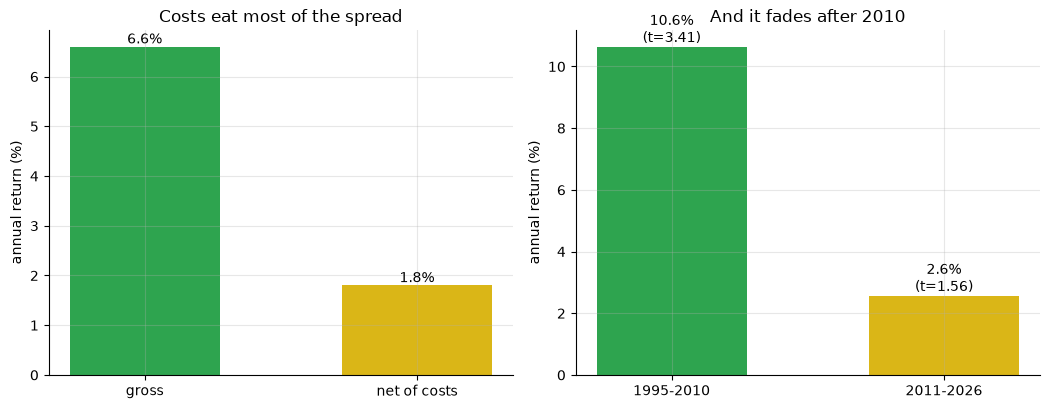

gross 6.6% -> net 1.8%/yr; modern-era t=1.56 (below the bar)


In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.bar(['gross','net of costs'], [R['gross_ann'], R['net_ann']], color=[GREEN, AMBER], width=.55)
for i,v in enumerate([R['gross_ann'], R['net_ann']]): a1.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
a1.set_ylabel('annual return (%)'); a1.set_title('Costs eat most of the spread')
labels = [s[0] for s in R['sub']]; anns = [s[1] for s in R['sub']]; ts = [s[2] for s in R['sub']]
bars = a2.bar(labels, anns, color=[GREEN if t>=2 else AMBER for t in ts], width=.55)
for i,(v,t) in enumerate(zip(anns,ts)): a2.annotate(f'{v:.1f}%\n(t={t:.2f})',(i,v),ha='center',va='bottom')
a2.set_ylabel('annual return (%)'); a2.set_title('And it fades after 2010')
plt.tight_layout(); plt.show()
print(f'gross {R["gross_ann"]:.1f}% -> net {R["net_ann"]:.1f}%/yr; modern-era t={R["sub"][1][2]:.2f} (below the bar)')

There's the wall. A **6.6%** gross spread becomes **1.8%** net once you pay to trade both legs every month (break-even is only **28 bps** — thin). And the early-era **10.6%/yr** effect fades to **2.6%/yr** (t = 1.56) after 2010. Add a short leg of illiquid, **hard-to-borrow** CEFs and tiny capacity, and the honest verdict isn't 'free money' — it's *'a real edge you can measure clearly and bank only weakly.'*

## 7 · Going further 🚪

- **Use real NAV.** Our discount is a *proxy* (price vs a benchmark). Plug in each fund's reported daily NAV (from a CEF data vendor) and re-run — the reversion should sharpen, but the costs and the fade won't budge.
- **Add the funds that died.** Our basket is **survivors**. Include CEFs that liquidated or merged and the edge likely **shrinks** — survivorship flatters a reversion bet.
- **Long-only, no shorting.** Drop the hard-to-borrow short leg and just overweight the cheap funds; the spread roughly halves but becomes actually executable.

*Think the discount is a clean free lunch? Add the dead funds, charge a realistic borrow on the shorts, and show it still clears the bar after 2010 — then we'll talk.*